# E207 Final: Fast Music Retrieval Under Time Warping

Collaborators: Jordan Carlin, Jasper Cox, Thomas Lilygren

Notes from Tsai:
Coarse quantization - too low move up higher iteratively
Block feature space into
Template with highest activation energy - most robust


In [1]:
%matplotlib inline

In [2]:
import numpy as np
import librosa as lb
import matplotlib.pyplot as plt
import IPython.display as ipd
import scipy.io as sio
import scipy.signal
import glob
import os.path
import subprocess
import pickle
import difflib
import string
from pathlib import Path
from typing import Literal
from sklearn.decomposition import non_negative_factorization as NMF

In [3]:
# Configuration
N_FFT = 2048
HOP_LENGTH = 512
EPS = np.finfo(np.float64).eps  # small constant to avoid division by zero
RANK = 4
LETTERS = list(string.ascii_lowercase)[0:RANK]

In [4]:
def load_audio(audio_file: Path) -> tuple[np.ndarray, int | float]:
    """
    Load an audio file. Returns a tuple of the audio time series and the sample rate.
    """
    audio, sr = lb.load(audio_file, sr=None)
    return audio, sr

In [5]:
def time_to_freq(audio: np.ndarray, sr: int | float, algorithm: Literal["stft", "cqt", "logmel", "chroma"] = "stft", n_fft: int = N_FFT, hop_length: int = HOP_LENGTH) -> np.ndarray:
    """
    Convert a time-domain audio signal to a frequency-domain representation.
    """
    match algorithm:
        case "stft":
            X = lb.stft(audio, n_fft=n_fft, hop_length=hop_length)
            return X
        case "cqt":
            C = lb.cqt(audio, sr=sr, hop_length=hop_length)
            return C
        case "logmel":
            S = lb.feature.melspectrogram(y=audio, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=128)
            log_S = lb.power_to_db(S, ref=np.max)
            return log_S
        case "chroma":
            C = lb.feature.chroma_stft(y=audio, sr=sr, n_fft=n_fft, hop_length=hop_length)
            return C
        case _:
            raise ValueError(f"Unsupported type: {algorithm}")

In [6]:
def extract_highest_energy(H: np.ndarray, median_frames: int = 21) -> np.ndarray:
    """For each time frame, return the index of the highest-activation component.

    Applies median filtering across time to smooth out frame-level noise.
    """
    H_smooth = scipy.signal.medfilt2d(H.astype(np.float64), kernel_size=(1, median_frames))
    dominant = np.argmax(H_smooth, axis=0)
    return dominant

In [7]:
def filter_and_collapse(dominant: np.ndarray, min_run: int = 3) -> np.ndarray:
    """Drop runs shorter than min_run frames, then collapse consecutive duplicates to one."""
    if len(dominant) == 0:
        return dominant

    changes = np.where(np.diff(dominant) != 0)[0] + 1
    starts = np.concatenate([[0], changes])
    ends = np.concatenate([changes, [len(dominant)]])

    kept = [dominant[s] for s, e in zip(starts, ends) if (e - s) >= min_run]

    if not kept:
        return np.array([], dtype=dominant.dtype)

    collapsed = [kept[0]]
    for v in kept[1:]:
        if v != collapsed[-1]:
            collapsed.append(v)

    return np.array(collapsed)

In [8]:
def test_single_file(audio_file: Path, n_components=RANK, max_frames=1000) -> None:
    audio, sr = load_audio(audio_file)
    X = time_to_freq(audio, sr, "stft")
    X = np.abs(X)

    W, H, n_iter = NMF(X, init="random", solver="mu", n_components=n_components, random_state=0)

    # Sort components by peak frequency so labels are consistent across recordings
    order = np.argsort(np.argmax(W, axis=0))
    W = W[:, order]
    H = H[order, :]

    H = H[:, :max_frames]

    dominant_component = extract_highest_energy(H)
    sequence = filter_and_collapse(dominant_component)

    plt.figure(figsize=(12, 4))
    plt.plot(sequence, drawstyle="steps-mid", linewidth=1.5)
    plt.yticks(range(n_components), LETTERS[:n_components])
    plt.xlabel("Event Index")
    plt.title("Dominant Note Sequence")
    plt.tight_layout()
    plt.show()

    print("Sequence:", "".join(LETTERS[i] for i in sequence))

songs/Sonata in C Minor, D958/MIDI-Unprocessed_Schubert1-3_MID--AUDIO_05_R2_2018_wav.wav


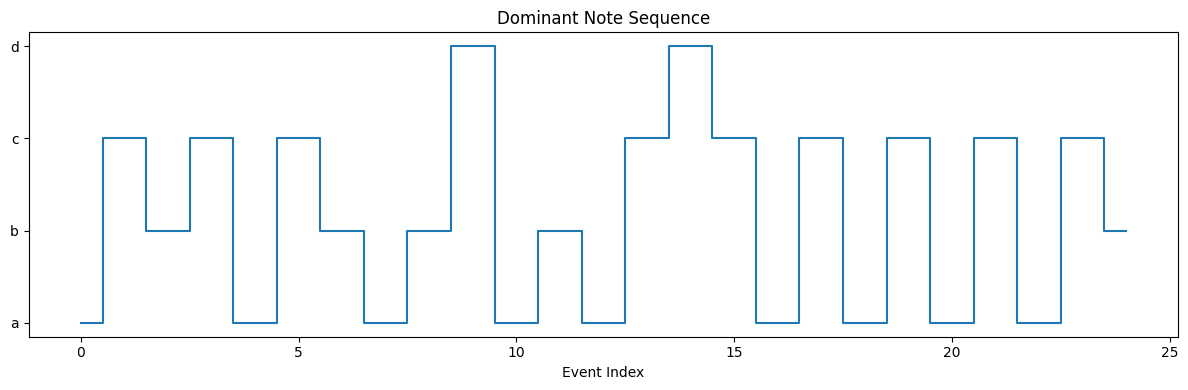

Sequence: acbcacbabdabacdcacacacacb
songs/Sonata in C Minor, D958/MIDI-Unprocessed_Schubert4-6_MID--AUDIO_08_R2_2018_wav.wav


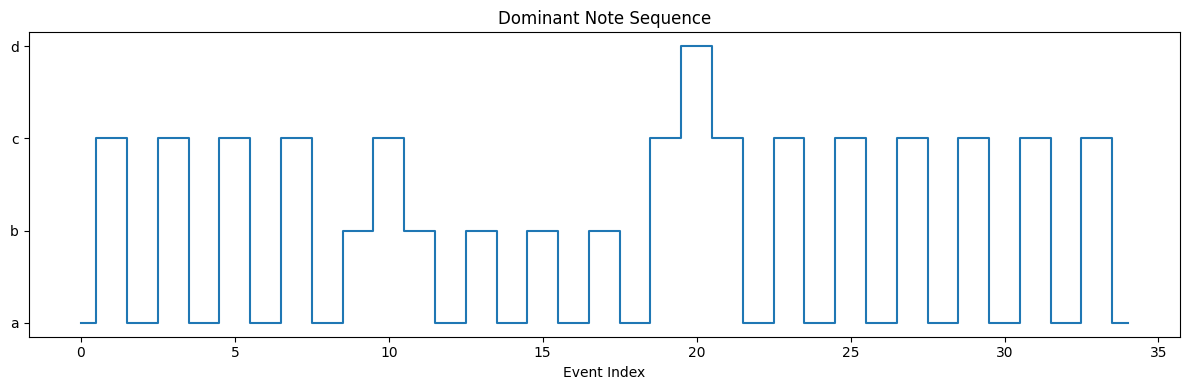

Sequence: acacacacabcbabababacdcacacacacacaca
songs/Sonata in C Minor, D958/MIDI-Unprocessed_Schubert7-9_MID--AUDIO_11_R2_2018_wav.wav


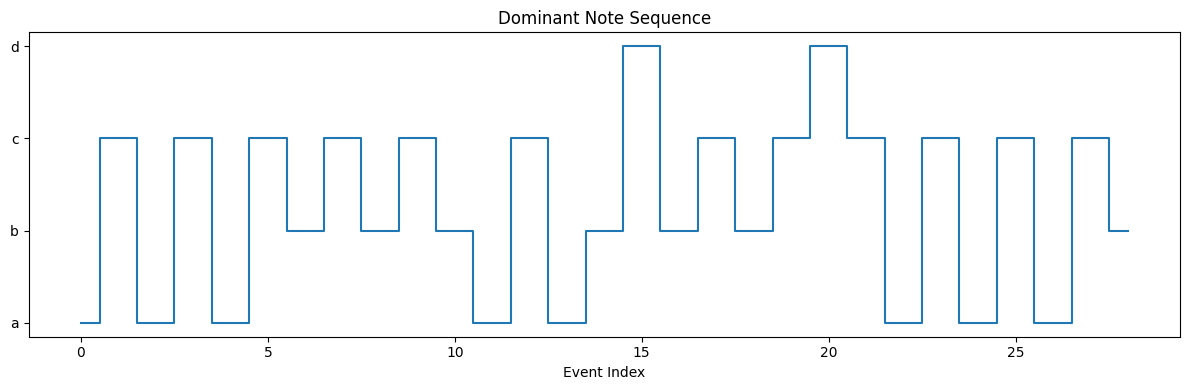

Sequence: acacacbcbcbacabdbcbcdcacacacb
songs/Sonata in C Minor, D958/MIDI-Unprocessed_Schubert7-9_MID--AUDIO_16_R2_2018_wav.wav


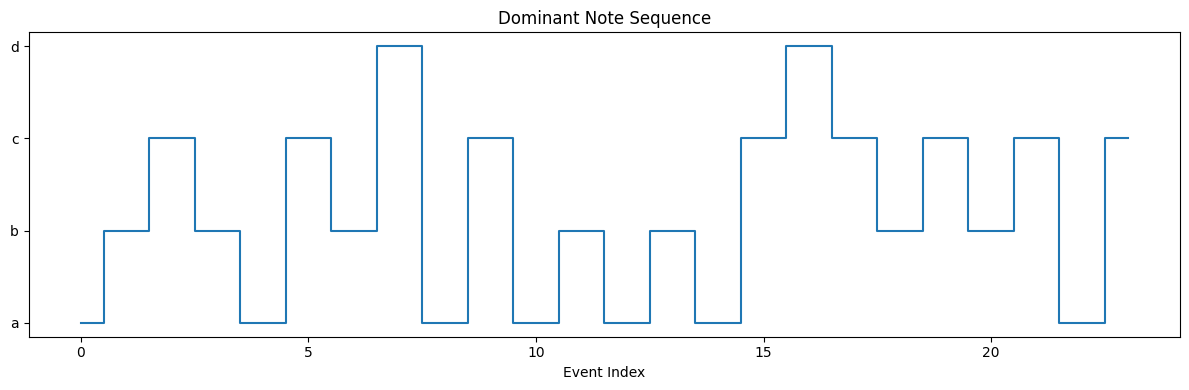

Sequence: abcbacbdacababacdcbcbcac
songs/Sonata in C Minor, D958/MIDI-Unprocessed_XP_06_R2_2004_01_ORIG_MID--AUDIO_06_R2_2004_01_Track01_wav.wav


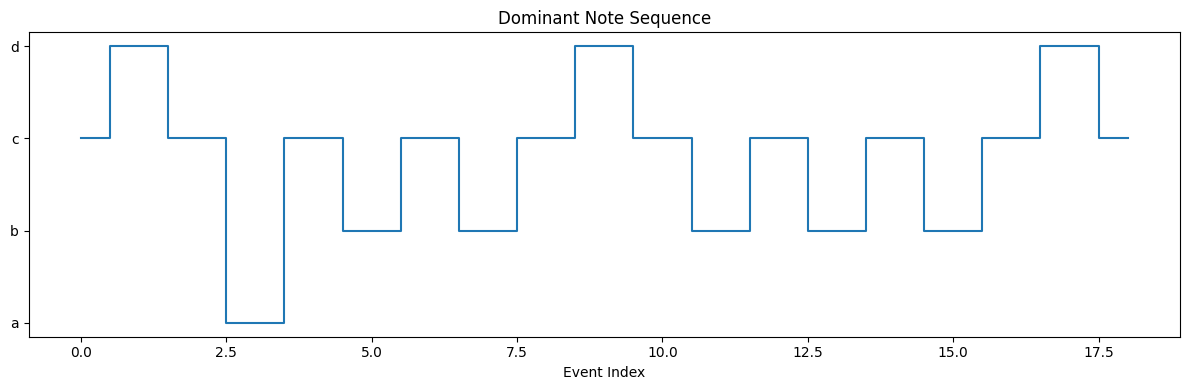

Sequence: cdcacbcbcdcbcbcbcdc
songs/Sonata in C Minor, D958/MIDI-Unprocessed_XP_06_R2_2004_01_ORIG_MID--AUDIO_06_R2_2004_02_Track02_wav.wav


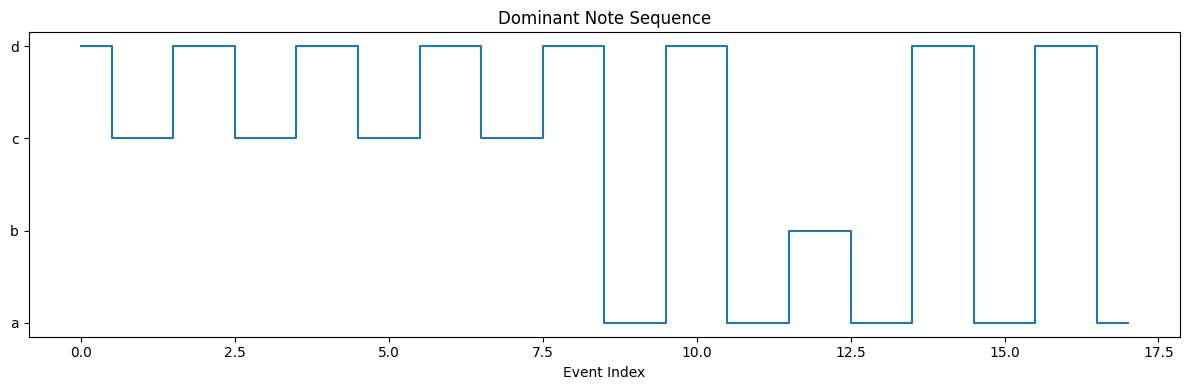

Sequence: dcdcdcdcdadabadada
songs/Sonata in C Minor, D958/MIDI-Unprocessed_XP_06_R2_2004_01_ORIG_MID--AUDIO_06_R2_2004_03_Track03_wav.wav


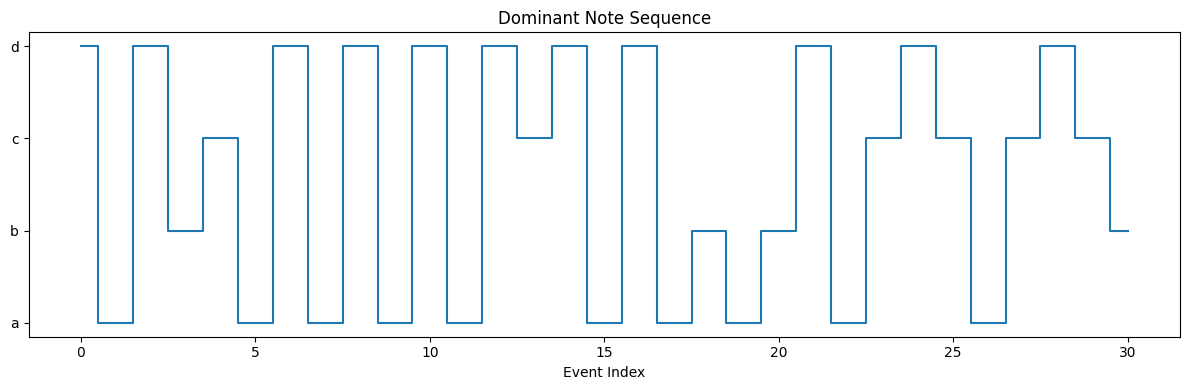

Sequence: dadbcadadadadcdadababdacdcacdcb
songs/Sonata in C Minor, D958/MIDI-Unprocessed_XP_19_R2_2004_01_ORIG_MID--AUDIO_19_R2_2004_01_Track01_wav.wav


/Users/jordancarlin/Documents/dsp/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


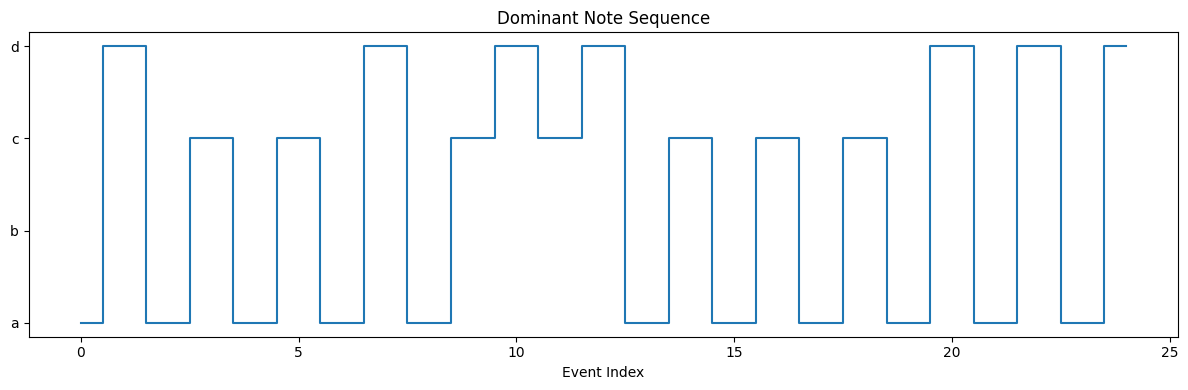

Sequence: adacacadacdcdacacacadadad
songs/Sonata in C Minor, D958/MIDI-Unprocessed_XP_19_R2_2004_01_ORIG_MID--AUDIO_19_R2_2004_02_Track02_wav.wav


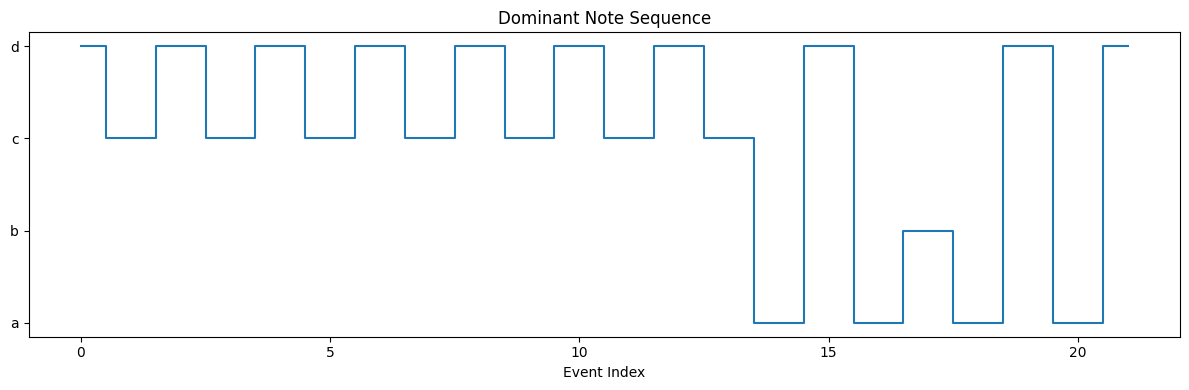

Sequence: dcdcdcdcdcdcdcadabadad
songs/Sonata in C Minor, D958/MIDI-Unprocessed_XP_19_R2_2004_01_ORIG_MID--AUDIO_19_R2_2004_03_Track03_wav.wav


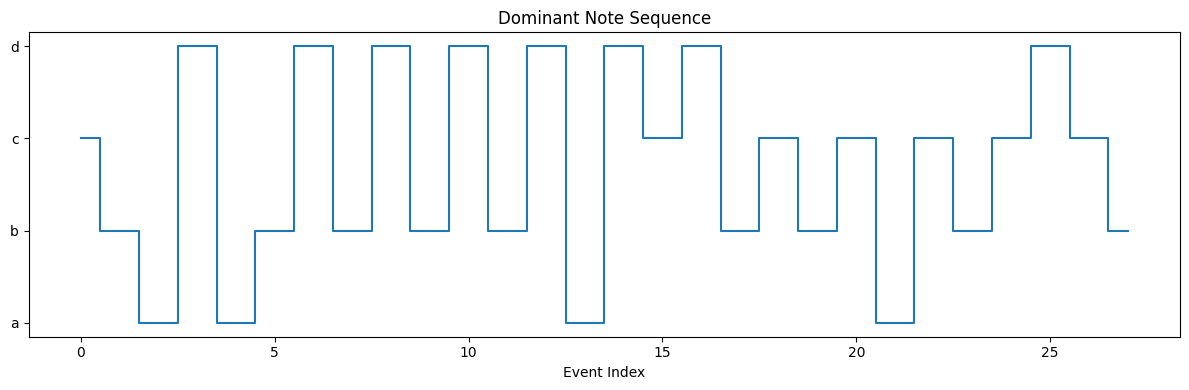

Sequence: cbadabdbdbdbdadcdbcbcacbcdcb
songs/Sonata in C Minor, D958/MIDI-Unprocessed_XP_22_R2_2004_01_ORIG_MID--AUDIO_22_R2_2004_01_Track01_wav.wav


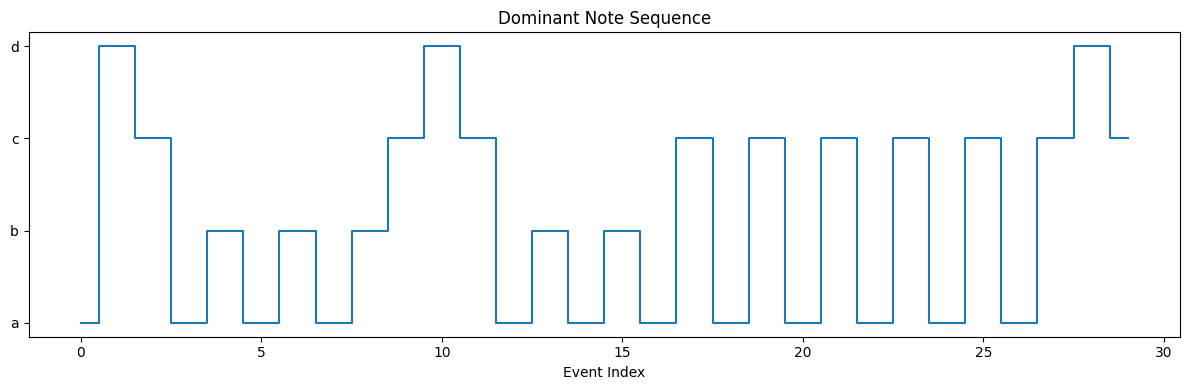

Sequence: adcabababcdcababacacacacacacdc
songs/Sonata in C Minor, D958/MIDI-Unprocessed_XP_22_R2_2004_01_ORIG_MID--AUDIO_22_R2_2004_02_Track02_wav.wav


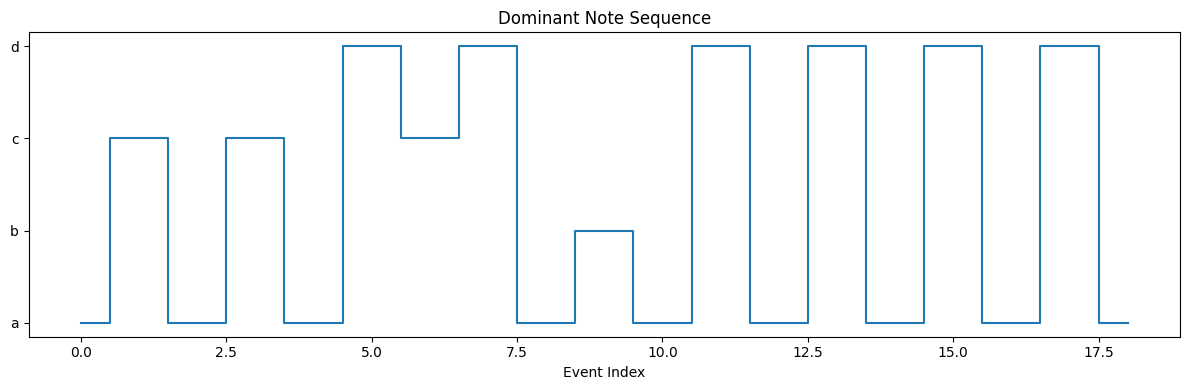

Sequence: acacadcdabadadadada
songs/Sonata in C Minor, D958/MIDI-Unprocessed_XP_22_R2_2004_01_ORIG_MID--AUDIO_22_R2_2004_03_Track03_wav.wav


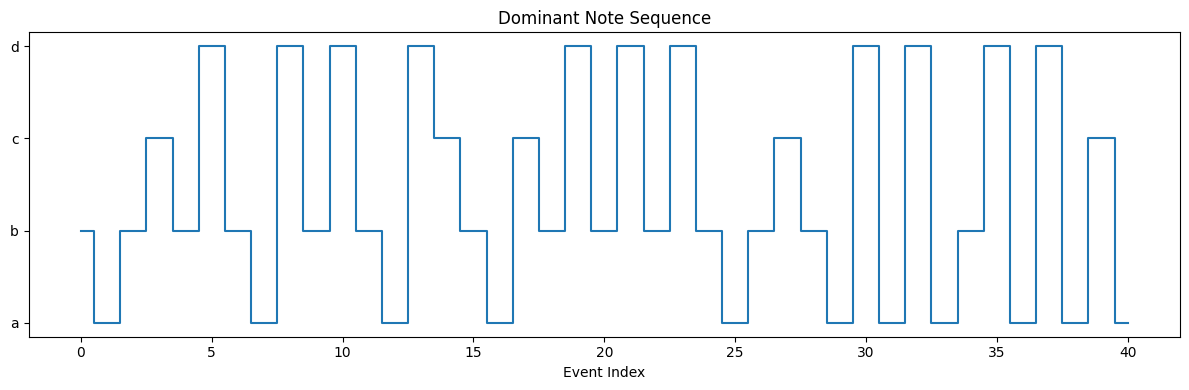

Sequence: babcbdbadbdbadcbacbdbdbdbabcbadadabdadaca
songs/Sonata in C Minor, D958/MIDI-Unprocessed_XP_22_R2_2004_01_ORIG_MID--AUDIO_22_R2_2004_04_Track04_wav.wav


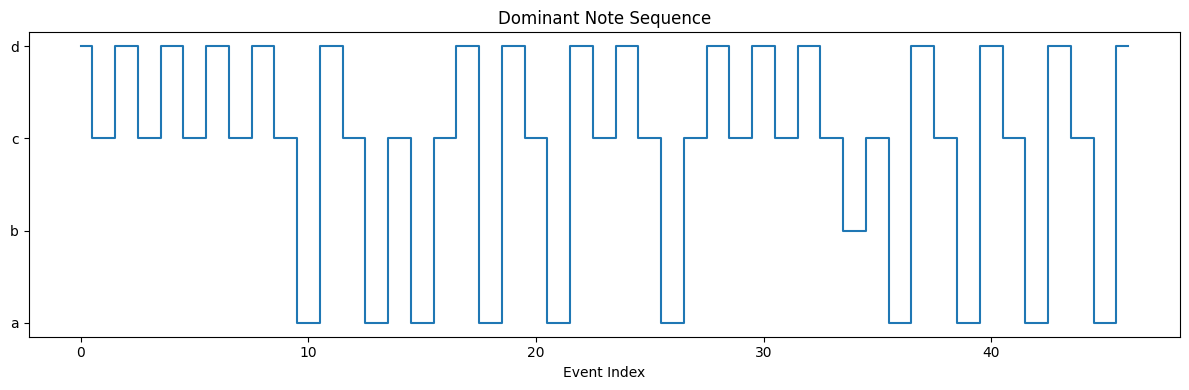

Sequence: dcdcdcdcdcadcacacdadcadcdcacdcdcdcbcadcadcadcad
songs/Thirty-Two Variations in C Minor, WoO 80/MIDI-Unprocessed_02_R3_2008_01-03_ORIG_MID--AUDIO_02_R3_2008_wav--1.wav


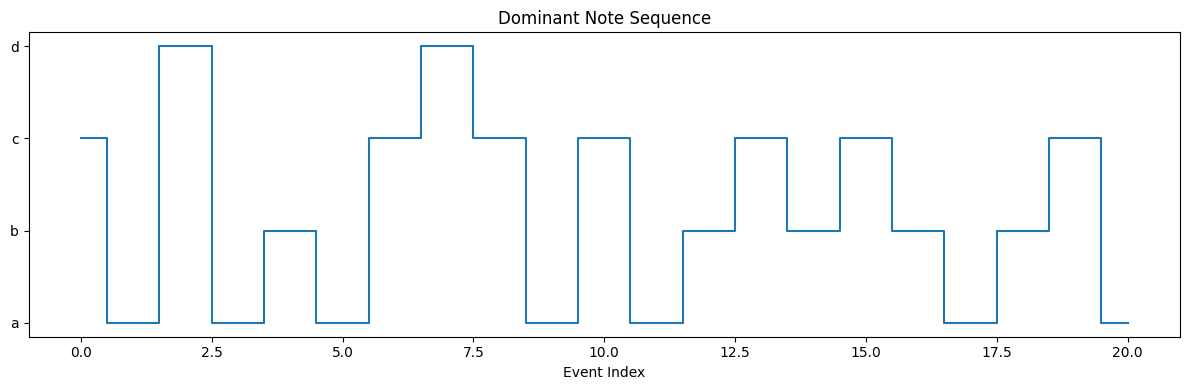

Sequence: cadabacdcacabcbcbabca
songs/Thirty-Two Variations in C Minor, WoO 80/MIDI-Unprocessed_03_R3_2008_01-03_ORIG_MID--AUDIO_03_R3_2008_wav--1.wav


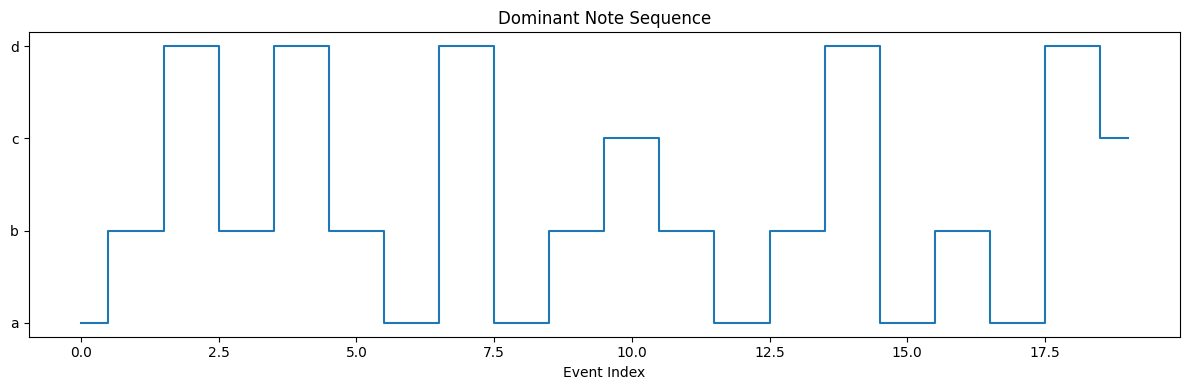

Sequence: abdbdbadabcbabdabadc
songs/Thirty-Two Variations in C Minor, WoO 80/MIDI-Unprocessed_04_R3_2008_01-07_ORIG_MID--AUDIO_04_R3_2008_wav--1.wav


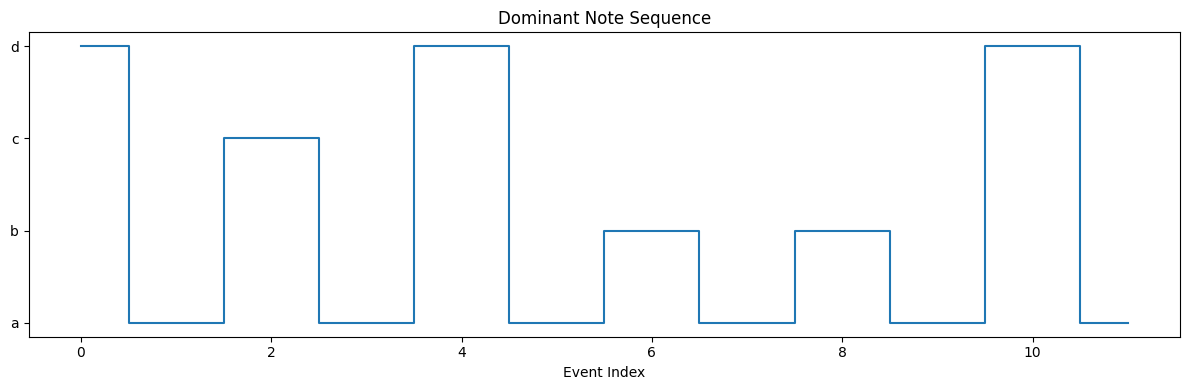

Sequence: dacadababada
songs/Thirty-Two Variations in C Minor, WoO 80/MIDI-Unprocessed_071_PIANO071_MID--AUDIO-split_07-08-17_Piano-e_1-04_wav--1.wav


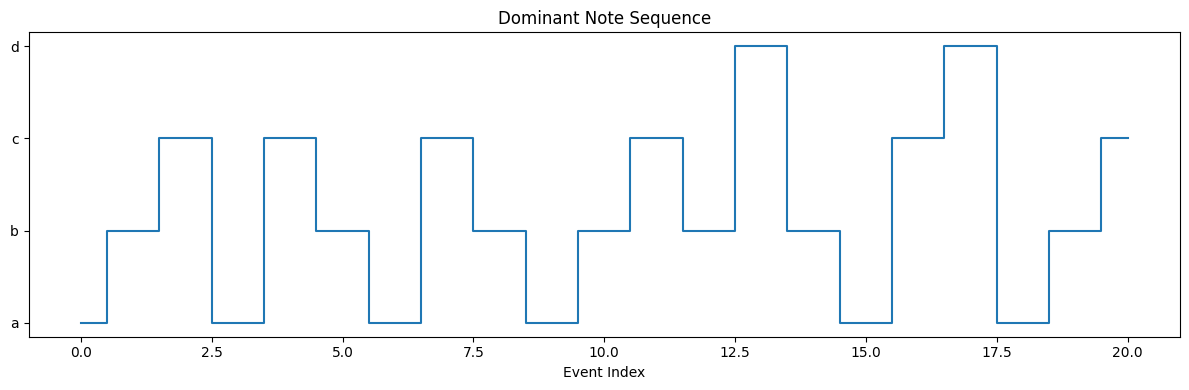

Sequence: abcacbacbabcbdbacdabc
songs/Thirty-Two Variations in C Minor, WoO 80/MIDI-Unprocessed_073_PIANO073_MID--AUDIO-split_07-08-17_Piano-e_2-02_wav--1.wav


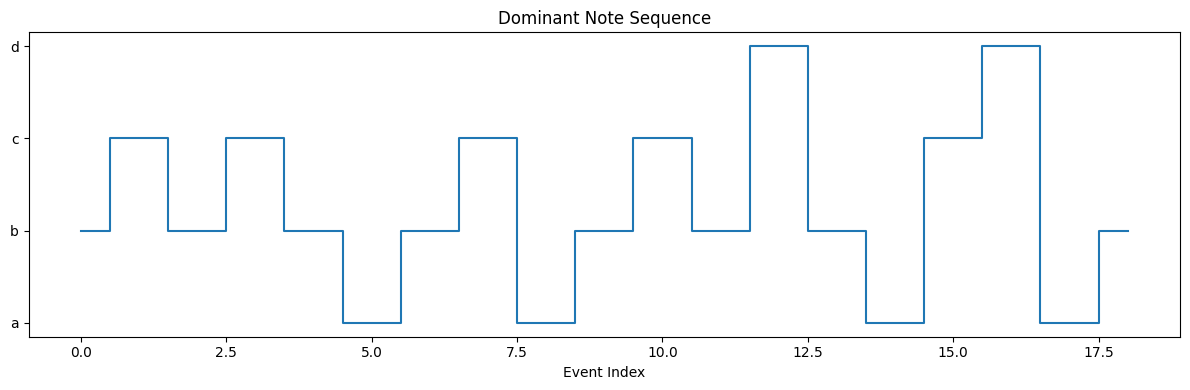

Sequence: bcbcbabcabcbdbacdab
songs/Thirty-Two Variations in C Minor, WoO 80/MIDI-Unprocessed_075_PIANO075_MID--AUDIO-split_07-08-17_Piano-e_2-06_wav--2.wav


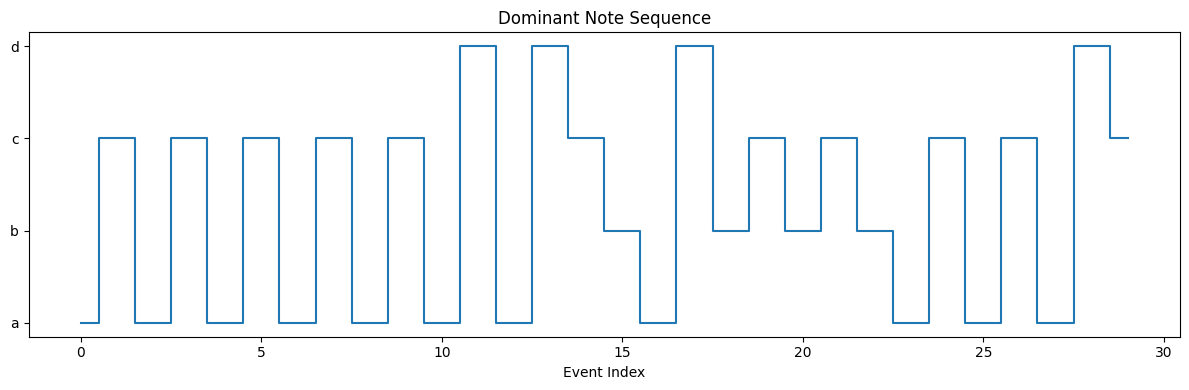

Sequence: acacacacacadadcbadbcbcbacacadc
songs/Thirty-Two Variations in C Minor, WoO 80/MIDI-Unprocessed_078_PIANO078_MID--AUDIO-split_07-09-17_Piano-e_1-02_wav--1.wav


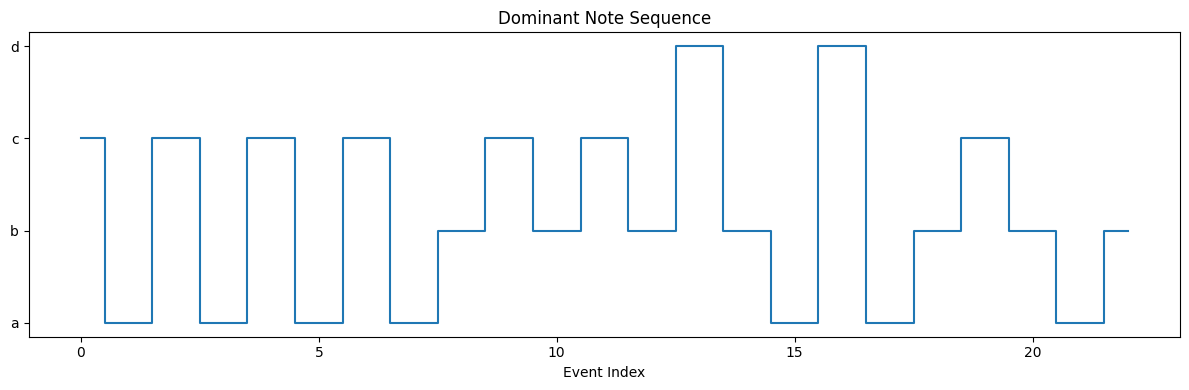

Sequence: cacacacabcbcbdbadabcbab
songs/Thirty-Two Variations in C Minor, WoO 80/MIDI-Unprocessed_079_PIANO079_MID--AUDIO-split_07-09-17_Piano-e_1-04_wav--3.wav


/Users/jordancarlin/Documents/dsp/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


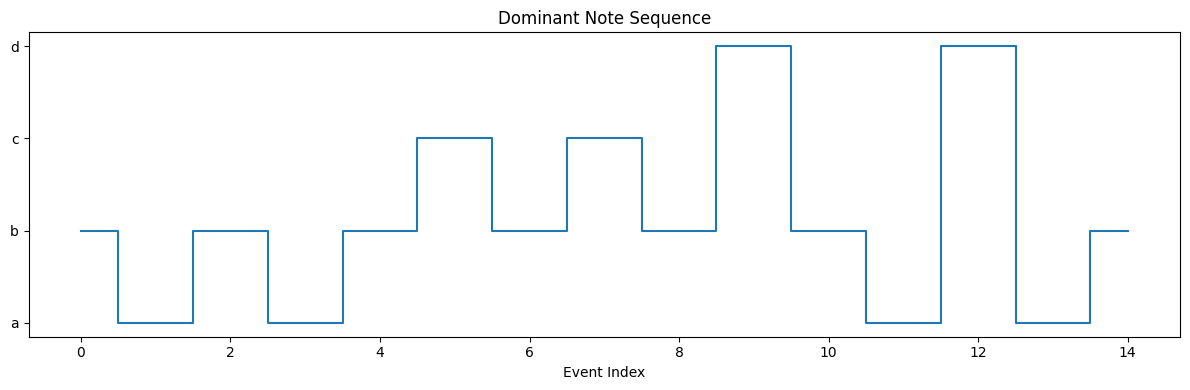

Sequence: bababcbcbdbadab
songs/Thirty-Two Variations in C Minor, WoO 80/MIDI-Unprocessed_080_PIANO080_MID--AUDIO-split_07-09-17_Piano-e_1-06_wav--2.wav


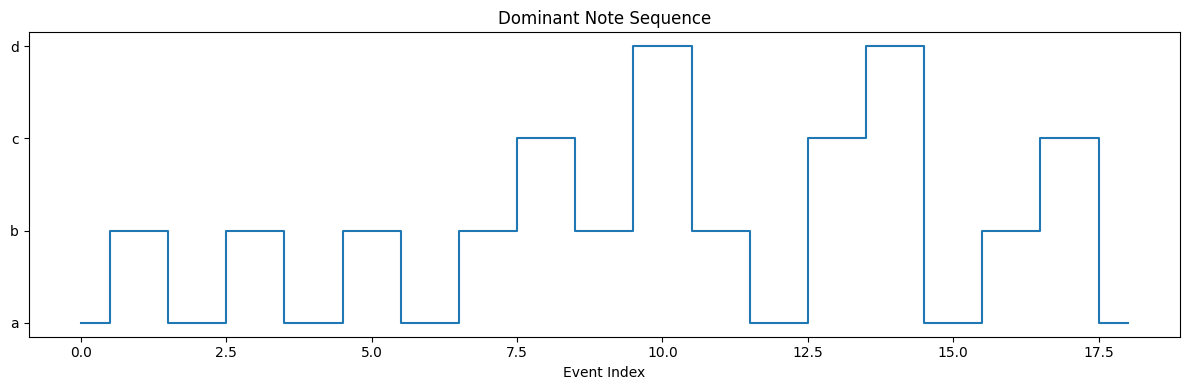

Sequence: ababababcbdbacdabca
songs/Thirty-Two Variations in C Minor, WoO 80/MIDI-Unprocessed_082_PIANO082_MID--AUDIO-split_07-09-17_Piano-e_2_-04_wav--1.wav


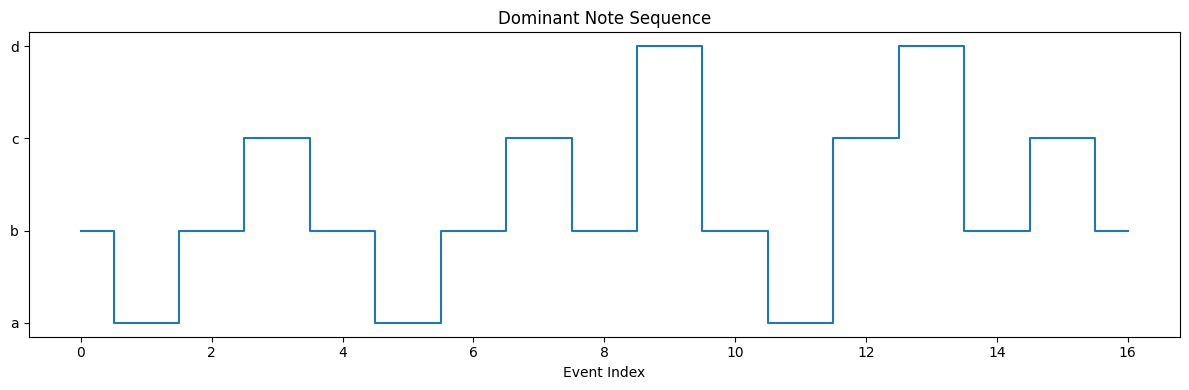

Sequence: babcbabcbdbacdbcb
songs/Thirty-Two Variations in C Minor, WoO 80/MIDI-Unprocessed_09_R3_2008_01-07_ORIG_MID--AUDIO_09_R3_2008_wav--4.wav


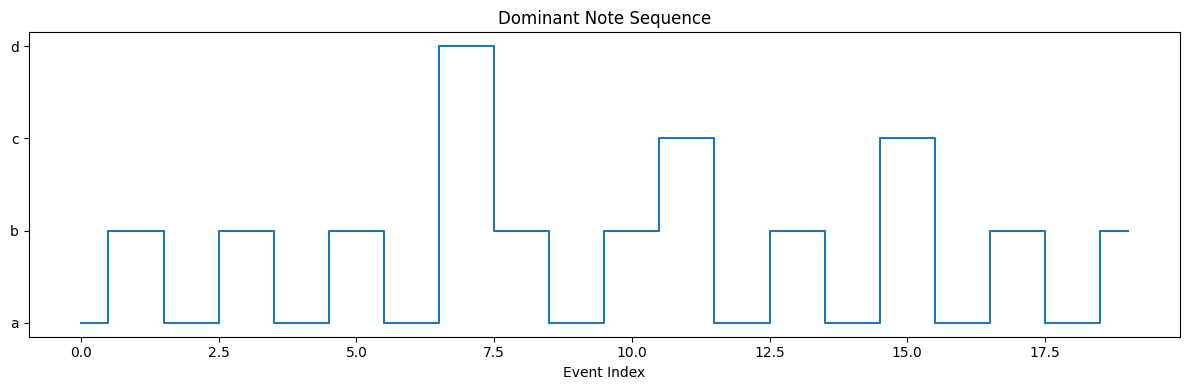

Sequence: abababadbabcabacabab
songs/Thirty-Two Variations in C Minor, WoO 80/MIDI-Unprocessed_12_R3_2008_01-04_ORIG_MID--AUDIO_12_R3_2008_wav--1.wav


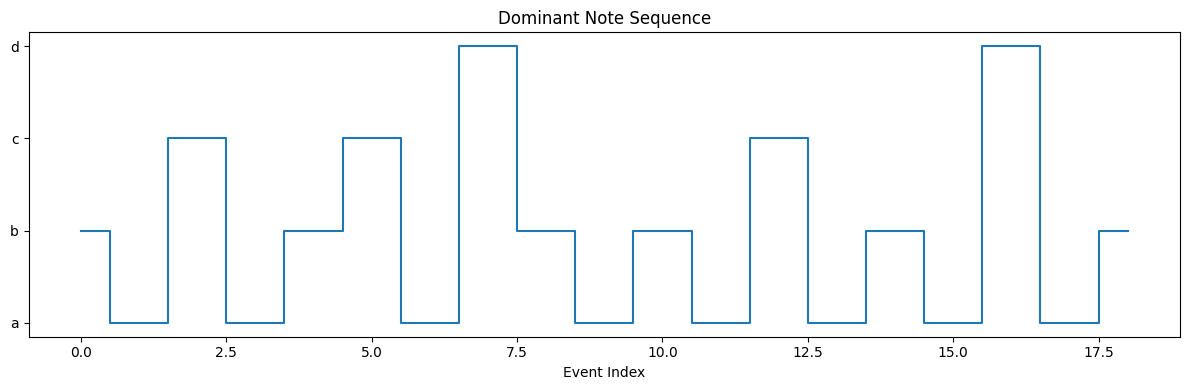

Sequence: bacabcadbabacabadab
songs/Thirty-Two Variations in C Minor, WoO 80/MIDI-Unprocessed_R2_D2-12-13-15_mid--AUDIO-from_mp3_12_R2_2015_wav--1.wav


/Users/jordancarlin/Documents/dsp/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


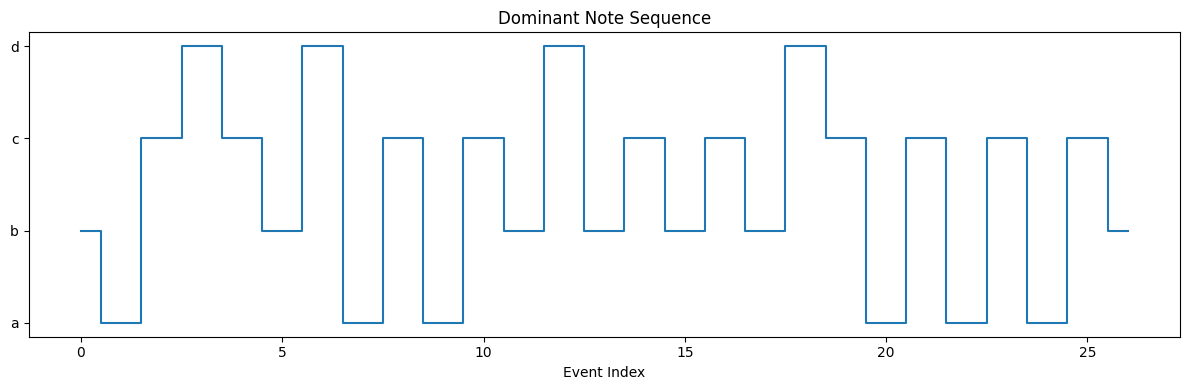

Sequence: bacdcbdacacbdbcbcbdcacacacb
songs/Thirty-Two Variations in C Minor, WoO 80/MIDI-Unprocessed_R2_D2-19-21-22_mid--AUDIO-from_mp3_21_R2_2015_wav--2.wav


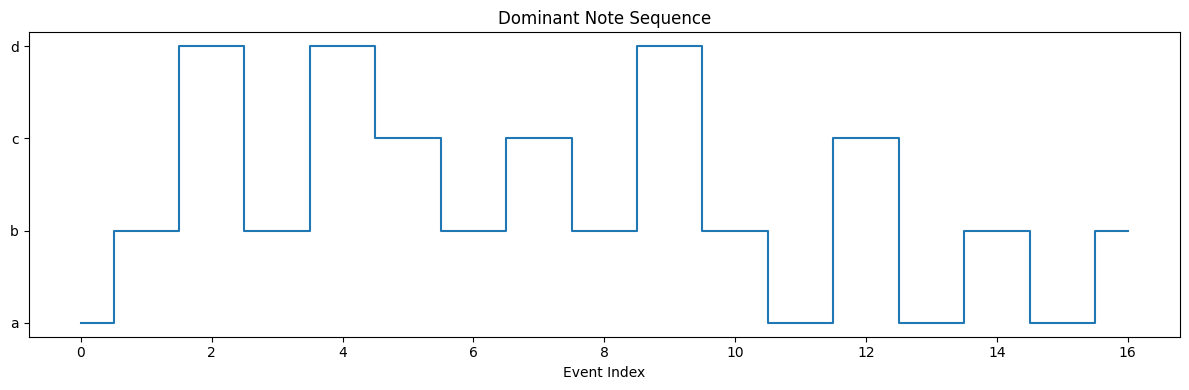

Sequence: abdbdcbcbdbacabab
songs/Thirty-Two Variations in C Minor, WoO 80/MIDI-Unprocessed_R2_D2-19-21-22_mid--AUDIO-from_mp3_22_R2_2015_wav--2.wav


/Users/jordancarlin/Documents/dsp/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


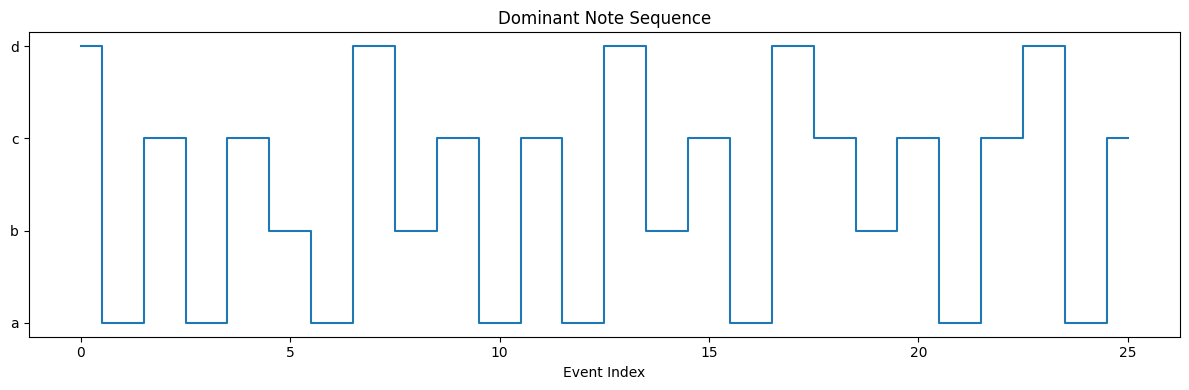

Sequence: dacacbadbcacadbcadcbcacdac
songs/Thirty-Two Variations in C Minor, WoO 80/ORIG-MIDI_01_7_10_13_Group_MID--AUDIO_07_R3_2013_wav--2.wav


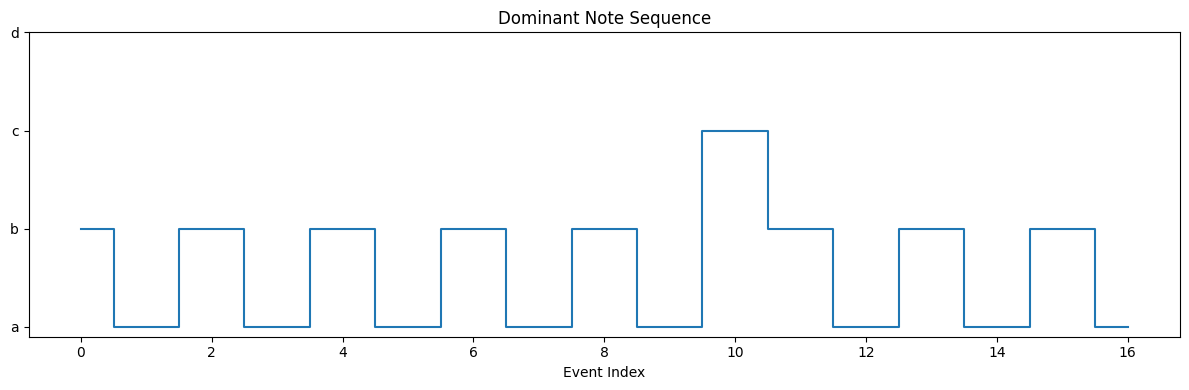

Sequence: bababababacbababa
songs/Thirty-Two Variations in C Minor, WoO 80/ORIG-MIDI_01_7_10_13_Group_MID--AUDIO_08_R3_2013_wav--1.wav


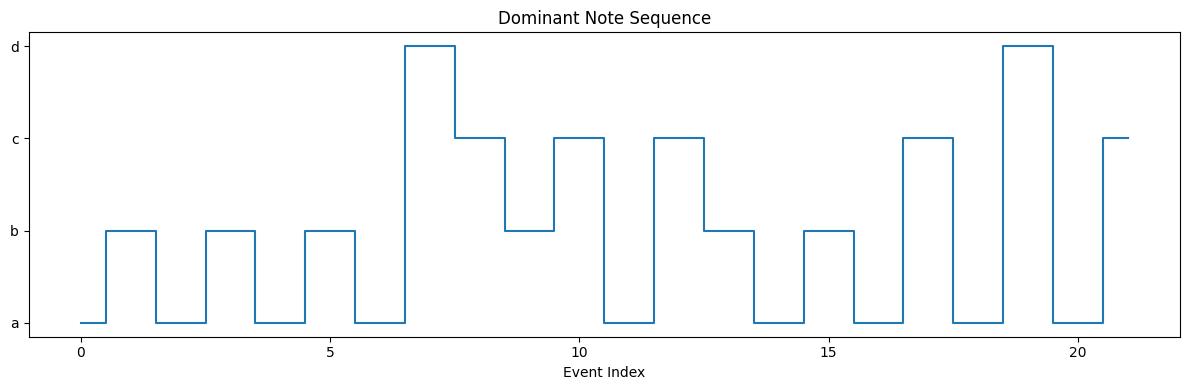

Sequence: abababadcbcacbabacadac
songs/Thirty-Two Variations in C Minor, WoO 80/ORIG-MIDI_02_7_10_13_Group_MID--AUDIO_12_R3_2013_wav--1.wav


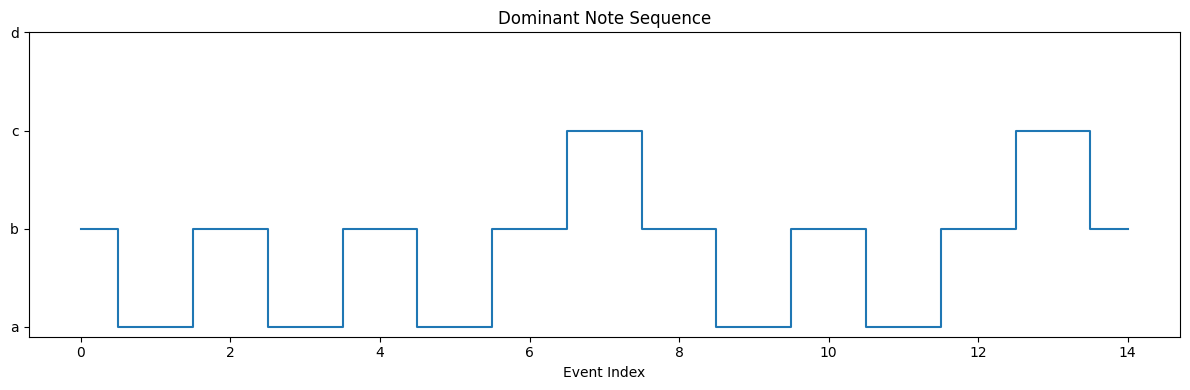

Sequence: babababcbababcb
songs/Variations Serieuses, Op. 54/MIDI-Unprocessed_03_R3_2011_MID--AUDIO_R3-D1_04_Track04_wav.wav


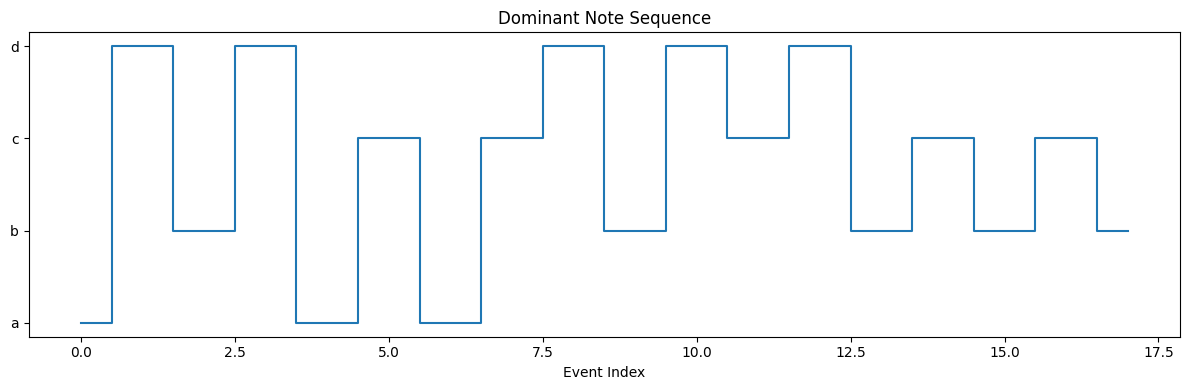

Sequence: adbdacacdbdcdbcbcb
songs/Variations Serieuses, Op. 54/MIDI-Unprocessed_04_R3_2011_MID--AUDIO_R3-D2_04_Track04_wav.wav


/Users/jordancarlin/Documents/dsp/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


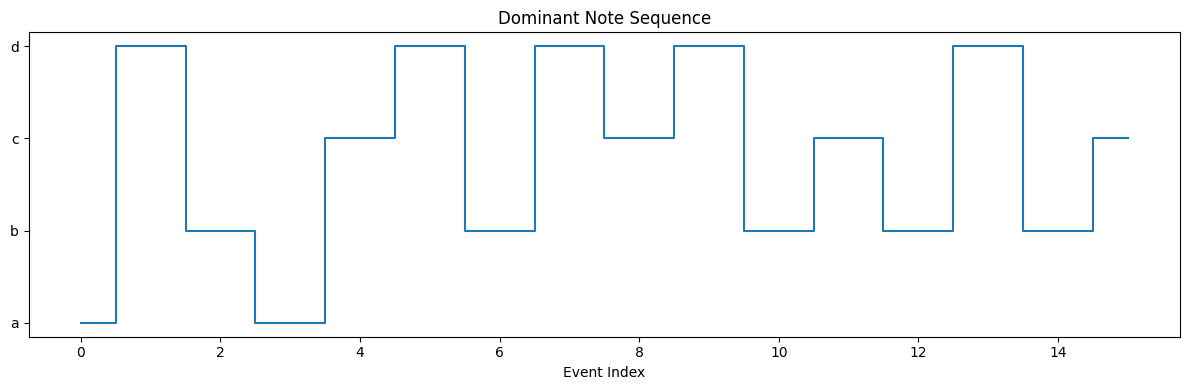

Sequence: adbacdbdcdbcbdbc
songs/Variations Serieuses, Op. 54/MIDI-Unprocessed_06_R3_2011_MID--AUDIO_R3-D3_02_Track02_wav.wav


/Users/jordancarlin/Documents/dsp/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


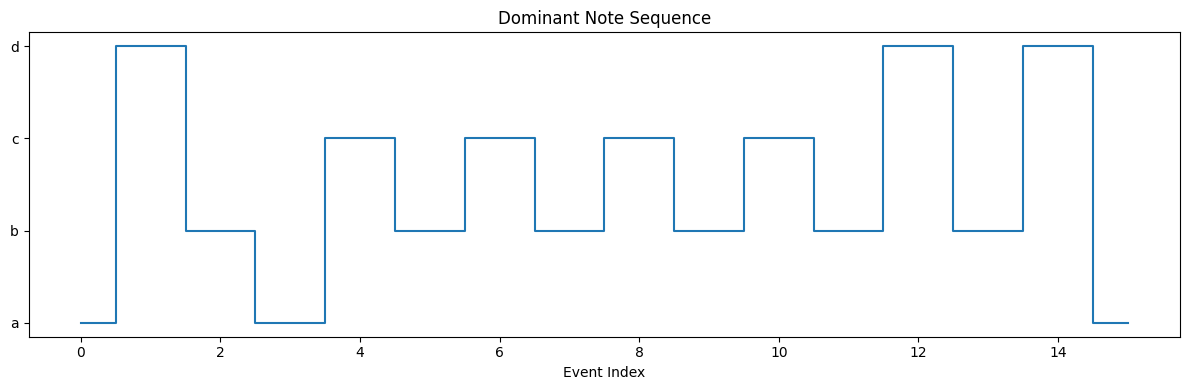

Sequence: adbacbcbcbcbdbda
songs/Variations Serieuses, Op. 54/MIDI-Unprocessed_08_R3_2008_01-05_ORIG_MID--AUDIO_08_R3_2008_wav--3.wav


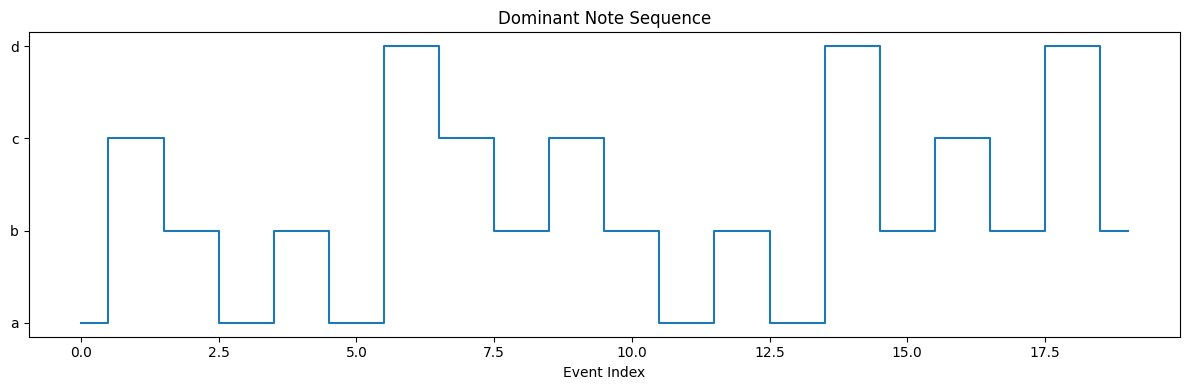

Sequence: acbabadcbcbabadbcbdb
songs/Variations Serieuses, Op. 54/MIDI-Unprocessed_10_R3_2008_01-05_ORIG_MID--AUDIO_10_R3_2008_wav--1.wav


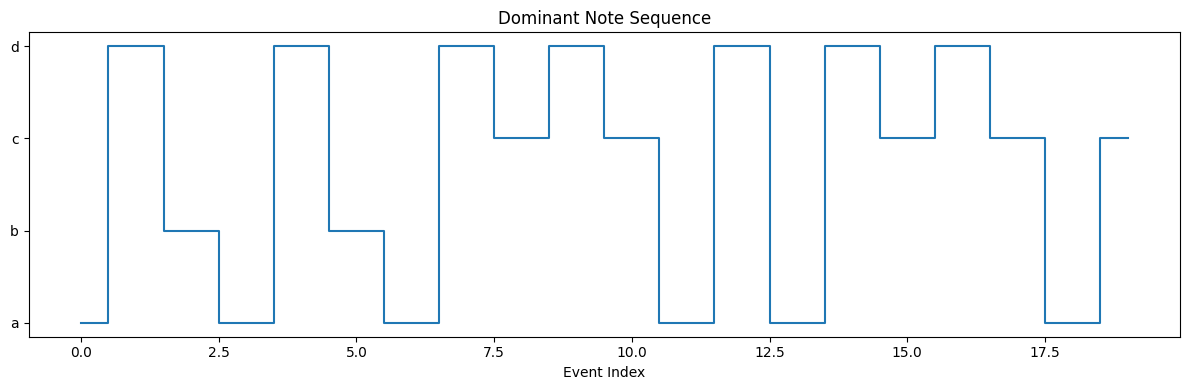

Sequence: adbadbadcdcadadcdcac
songs/Variations Serieuses, Op. 54/MIDI-Unprocessed_11_R3_2008_01-04_ORIG_MID--AUDIO_11_R3_2008_wav--2.wav


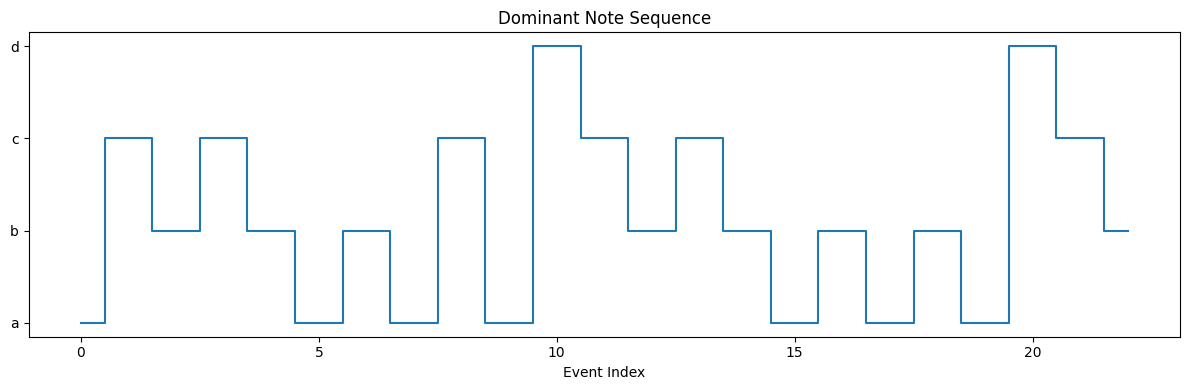

Sequence: acbcbabacadcbcbababadcb
songs/Variations Serieuses, Op. 54/MIDI-Unprocessed_23_R3_2011_MID--AUDIO_R3-D8_05_Track05_wav.wav


/Users/jordancarlin/Documents/dsp/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


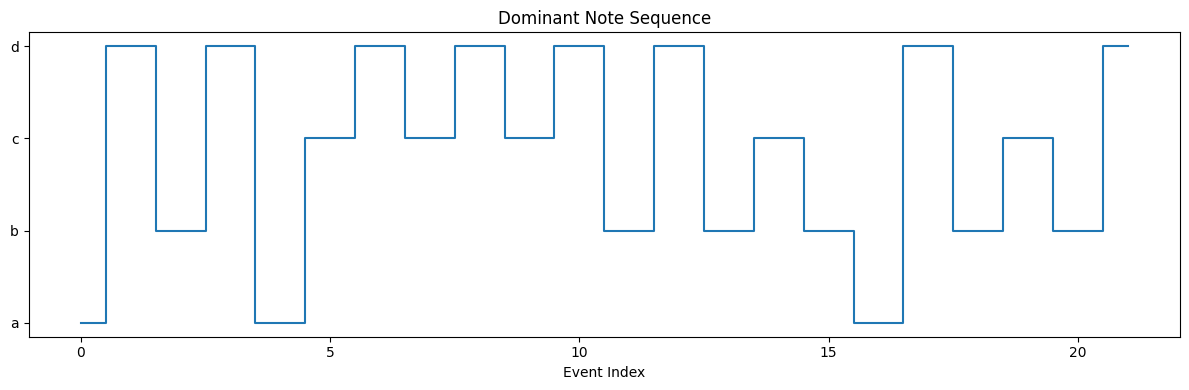

Sequence: adbdacdcdcdbdbcbadbcbd
songs/Variations Serieuses, Op. 54/MIDI-Unprocessed_R2_D1-2-3-6-7-8-11_mid--AUDIO-from_mp3_03_R2_2015_wav--2.wav


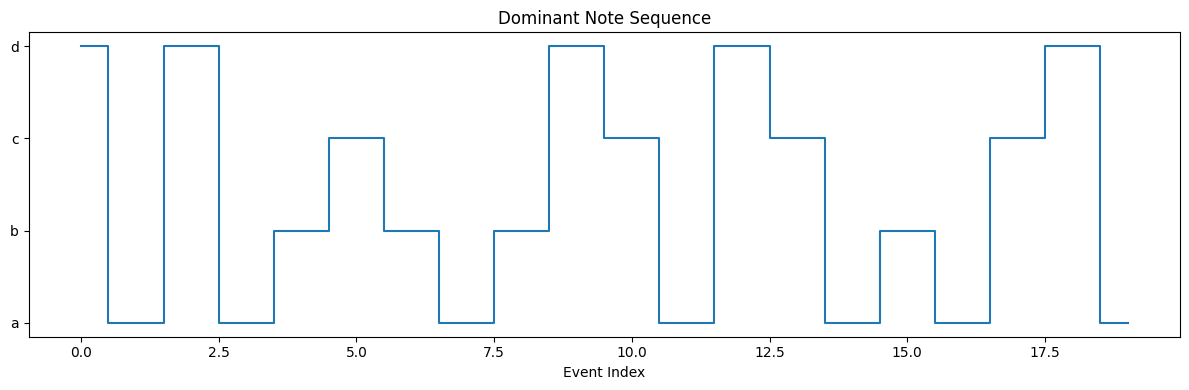

Sequence: dadabcbabdcadcabacda
songs/Variations Serieuses, Op. 54/MIDI-Unprocessed_R2_D1-2-3-6-7-8-11_mid--AUDIO-from_mp3_07_R2_2015_wav--2.wav


/Users/jordancarlin/Documents/dsp/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


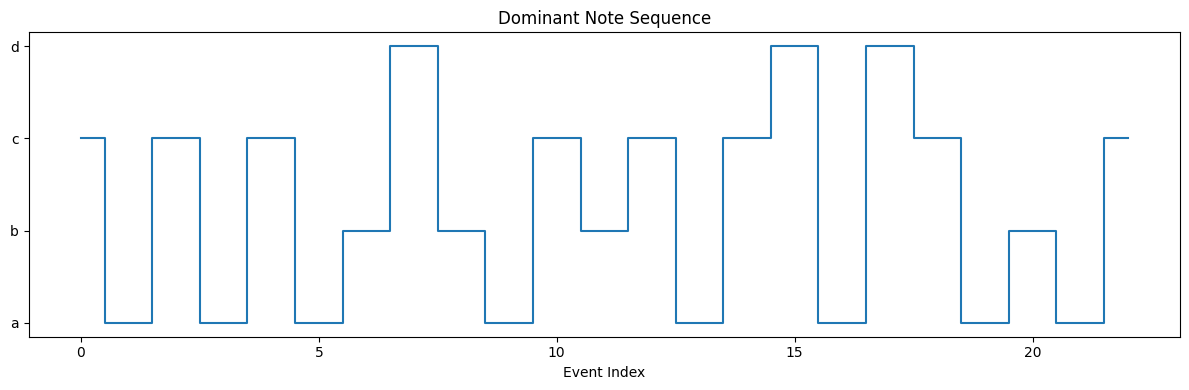

Sequence: cacacabdbacbcacdadcabac
songs/Variations Serieuses, Op. 54/ORIG-MIDI_01_7_10_13_Group_MID--AUDIO_02_R3_2013_wav--1.wav


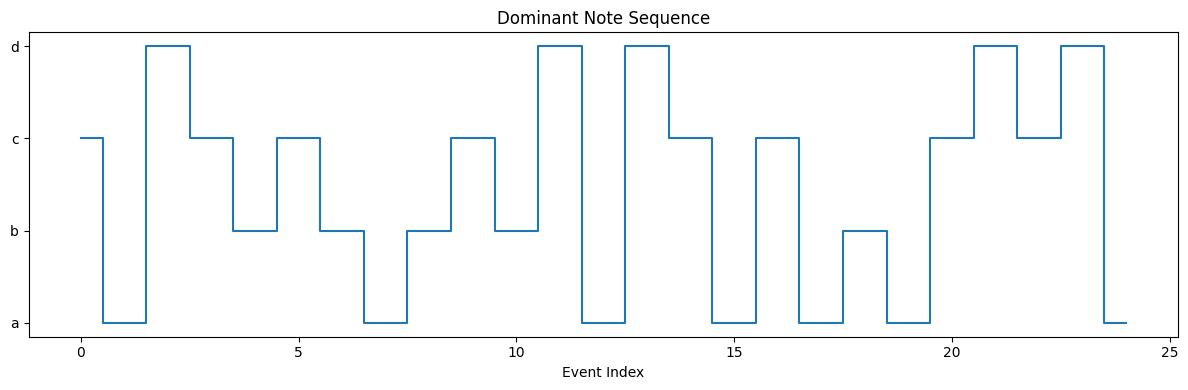

Sequence: cadcbcbabcbdadcacabacdcda
songs/Variations Serieuses, Op. 54/ORIG-MIDI_02_7_10_13_Group_MID--AUDIO_11_R3_2013_wav--1.wav


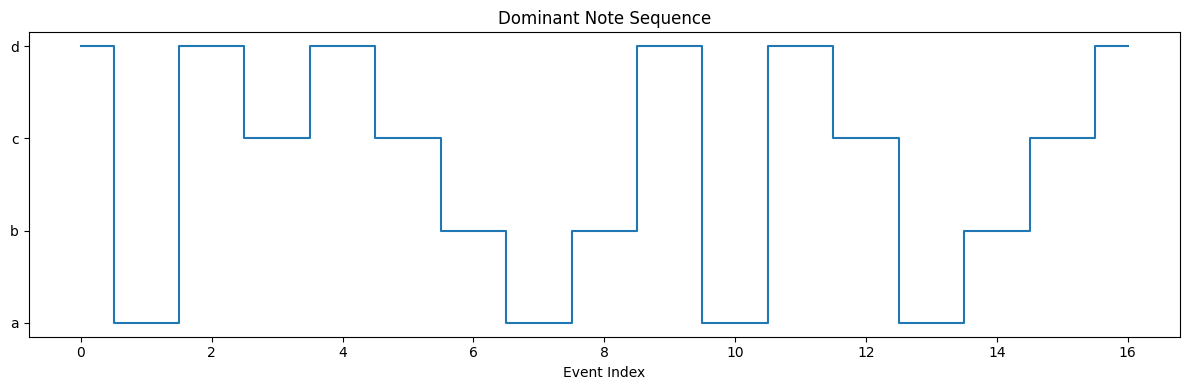

Sequence: dadcdcbabdadcabcd
songs/Variations Serieuses, Op. 54/ORIG-MIDI_03_7_10_13_Group_MID--AUDIO_15_R3_2013_wav--1.wav


/Users/jordancarlin/Documents/dsp/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


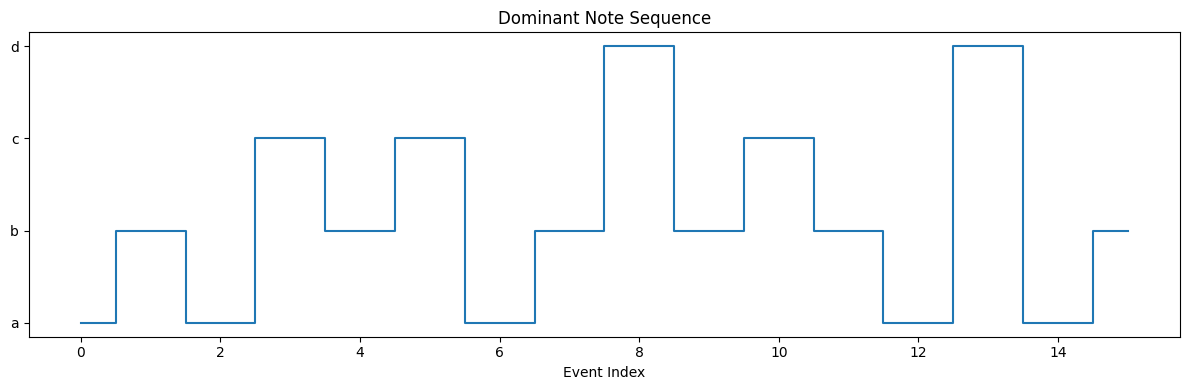

Sequence: abacbcabdbcbadab
songs/Variations Serieuses, Op. 54/ORIG-MIDI_03_7_10_13_Group_MID--AUDIO_17_R3_2013_wav--2.wav


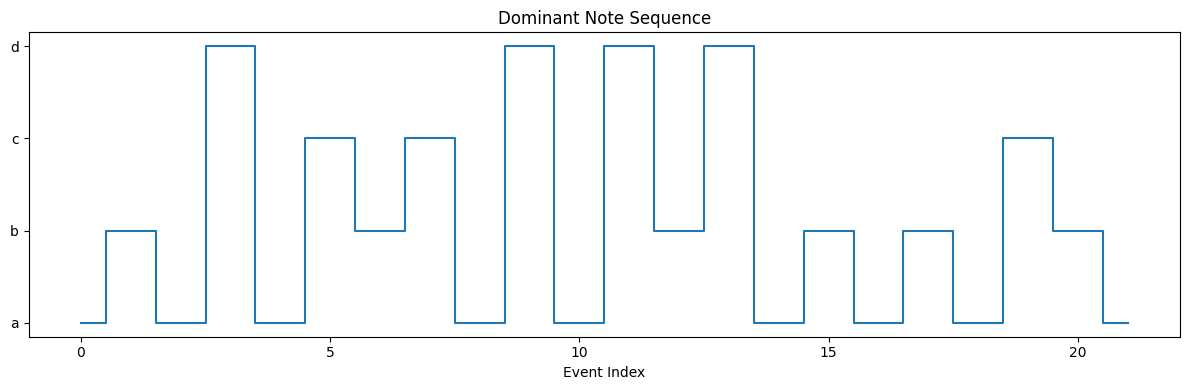

Sequence: abadacbcadadbdababacba
songs/Variations Serieuses, Op. 54/ORIG-MIDI_03_7_10_13_Group_MID--AUDIO_18_R3_2013_wav--3.wav


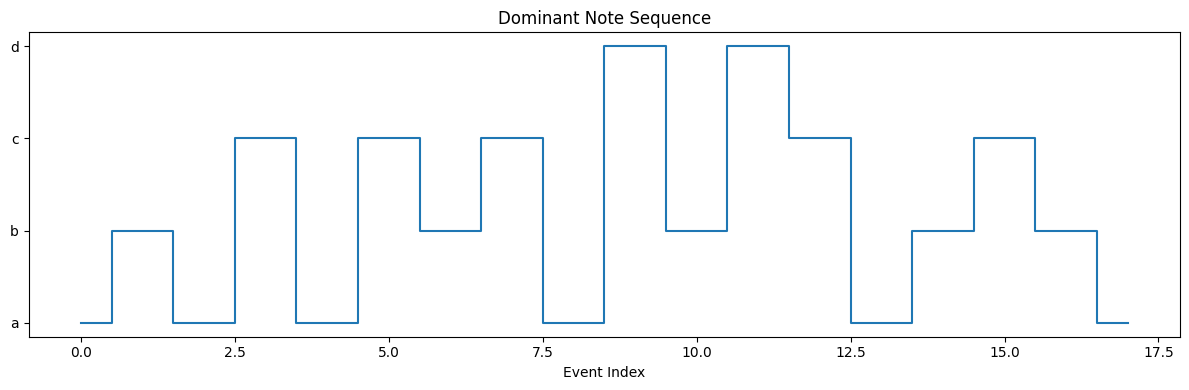

Sequence: abacacbcadbdcabcba


In [9]:
songs_dir = Path("./songs")
for audio_file in sorted(songs_dir.rglob("*.wav")):
    print(audio_file)
    test_single_file(audio_file)